In [1]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_IMG_DIR = "/content/drive/MyDrive/Dataset/GIDsplit/train/image_RGB"
TRAIN_MASK_DIR = "/content/drive/MyDrive/Dataset/GIDsplit/train/label"
VAL_IMG_DIR   = "/content/drive/MyDrive/Dataset/GIDsplit/val/image_RGB"
VAL_MASK_DIR  = "/content/drive/MyDrive/Dataset/GIDsplit/val/label"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, time, random, numpy as np, gc
from pathlib import Path
from PIL import Image

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)


CLASS_COLORS = [
    (0, 0, 0),      # 0 background
    (255, 0, 0),    # 1 build-up
    (255, 255, 0),  # 2 farmland
    (0, 255, 0),    # 3 forest
    (0, 255, 255),  # 4 meadow
    (0, 0, 255),    # 5 water
]
CLASS_NAMES  = ["background","build-up","farmland","forest","meadow","water"]
NUM_CLASSES  = len(CLASS_COLORS)

IMG_EXTS  = {".png",".jpg",".jpeg",".bmp",".tif",".tiff"}
MASK_EXTS = [".png",".tif",".tiff",".jpg",".jpeg",".bmp"]


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self,in_ch,out_ch):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,padding=1,bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(True),
            nn.Conv2d(out_ch,out_ch,3,padding=1,bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(True),
        )
    def forward(self,x): return self.seq(x)

class UNet(nn.Module):
    def __init__(self,in_ch=3,num_classes=6,base_ch=64):
        super().__init__()
        self.inc=DoubleConv(in_ch,base_ch)
        self.d1=nn.Sequential(nn.MaxPool2d(2),DoubleConv(base_ch,base_ch*2))
        self.d2=nn.Sequential(nn.MaxPool2d(2),DoubleConv(base_ch*2,base_ch*4))
        self.d3=nn.Sequential(nn.MaxPool2d(2),DoubleConv(base_ch*4,base_ch*8))
        self.d4=nn.Sequential(nn.MaxPool2d(2),DoubleConv(base_ch*8,base_ch*16))
        self.u1=nn.ConvTranspose2d(base_ch*16,base_ch*8,2,2); self.c1=DoubleConv(base_ch*16,base_ch*8)
        self.u2=nn.ConvTranspose2d(base_ch*8, base_ch*4,2,2); self.c2=DoubleConv(base_ch*8, base_ch*4)
        self.u3=nn.ConvTranspose2d(base_ch*4, base_ch*2,2,2); self.c3=DoubleConv(base_ch*4, base_ch*2)
        self.u4=nn.ConvTranspose2d(base_ch*2, base_ch,  2,2); self.c4=DoubleConv(base_ch*2, base_ch)
        self.outc=nn.Conv2d(base_ch,num_classes,1)
    def forward(self,x):
        x1=self.inc(x); x2=self.d1(x1); x3=self.d2(x2); x4=self.d3(x3); x5=self.d4(x4)
        x=self.u1(x5); x=torch.cat([x,TF.center_crop(x4,x.shape[-2:])],1); x=self.c1(x)
        x=self.u2(x);  x=torch.cat([x,TF.center_crop(x3,x.shape[-2:])],1); x=self.c2(x)
        x=self.u3(x);  x=torch.cat([x,TF.center_crop(x2,x.shape[-2:])],1); x=self.c3(x)
        x=self.u4(x);  x=torch.cat([x,TF.center_crop(x1,x.shape[-2:])],1); x=self.c4(x)
        return self.outc(x)


def compute_confusion_matrix(pred: torch.Tensor, target: torch.Tensor, num_classes: int) -> torch.Tensor:
    k = (target >= 0) & (target < num_classes)
    inds = num_classes * target[k].to(torch.int64) + pred[k]
    return torch.bincount(inds, minlength=num_classes**2).reshape(num_classes, num_classes)

def metrics_from_cm(cm: torch.Tensor):
    cm = cm.to(torch.float32)
    tp = cm.diag()
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    iou = tp / (tp + fp + fn).clamp_min(1e-6)
    miou = float(iou.mean().item())
    support = cm.sum(1)
    pa = tp / support.clamp_min(1e-6)
    valid = support > 0
    mpa = float(pa[valid].mean().item()) if valid.any() else float("nan")
    oa = float((tp.sum() / cm.sum().clamp_min(1e-6)).item())
    return iou.tolist(), miou, pa.tolist(), mpa, oa


In [ ]:
@torch.no_grad()
def validate(model, loader, device, amp=True):
    model.eval()
    cm_total = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64)
    tot_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        with torch.autocast(device_type="cuda" if device.type=="cuda" else "cpu",
                             enabled=amp, dtype=torch.float16):
            logits = model(xb)
            loss = criterion(logits, yb)
        tot_loss += float(loss.item()) * xb.size(0)
        preds = logits.argmax(1)
        cm_total += compute_confusion_matrix(preds.cpu(), yb.cpu(), NUM_CLASSES)
    iou, miou, pa, mpa, oa = metrics_from_cm(cm_total)
    return tot_loss/len(loader.dataset), cm_total, iou, miou, pa, mpa, oa

def train(train_loader, val_loader, epochs=20, lr=1e-3, weight_decay=1e-4,
          base_ch=64, mixed_precision=True, save_dir="/content/checkpoints_unet"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    torch.backends.cudnn.benchmark = True

    model = UNet(3, NUM_CLASSES, base_ch=base_ch).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=(mixed_precision and device.type=="cuda"))

    os.makedirs(save_dir, exist_ok=True)
    best_miou = -1.0
    last_cm = None

    for ep in range(epochs):
        model.train()
        run_loss, t0 = 0.0, time.time()
        for step, (xb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda" if device.type=="cuda" else "cpu",
                                 enabled=mixed_precision, dtype=torch.float16):
                logits = model(xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            run_loss += float(loss.item())

            if (step+1) % 50 == 0:
                print(f"Epoch {ep+1}/{epochs} | step {step+1}/{len(train_loader)} | "
                      f"loss {run_loss/(step+1):.4f}")

        sch.step()
        v_loss, cm, iou, miou, pa, mpa, oa = validate(model, val_loader, device, amp=mixed_precision)
        last_cm = cm.clone()
        print(f"Epoch {ep+1}: train_loss={run_loss/len(train_loader):.4f}, "
              f"val_loss={v_loss:.4f}, mIoU={miou:.4f}, mPA={mpa:.4f}, OA={oa:.4f}")
        for i,(ii,pp) in enumerate(zip(iou, pa)):
            print(f"  class {i} ({CLASS_NAMES[i]}): IoU={ii:.4f} | PA={pp:.4f}")

        is_best = miou > best_miou
        best_miou = max(best_miou, miou)
        torch.save(model.state_dict(), os.path.join(save_dir, f"epoch_{ep+1:03d}.pth"))
        if is_best:
            torch.save(model.state_dict(), os.path.join(save_dir, "best_model_state_dict.pth"))
            print(f"* New best mIoU {miou:.4f} — saved best.")
        if device.type=="cuda":
            torch.cuda.empty_cache(); gc.collect()

    return model, last_cm


@torch.no_grad()
def show_val_patches(model, val_loader, device=None, max_items=6, overlay_alpha=0.45):
    device = device or next(model.parameters()).device
    model.eval()
    xb, yb = next(iter(val_loader))
    xb = xb.to(device)
    with torch.autocast(device_type="cuda" if device.type=="cuda" else "cpu",
                         enabled=True, dtype=torch.float16):
        logits = model(xb)
    pred = logits.argmax(1).cpu().numpy()
    imgs = (xb.cpu().permute(0,2,3,1).numpy()*255).astype(np.uint8)
    gts  = yb.numpy()
    n = min(len(imgs), max_items)
    fig, axs = plt.subplots(n, 4, figsize=(16, 4*n))
    if n==1: axs = axs[None,:]
    for i in range(n):
        im = imgs[i]; gt=colorize_idx(gts[i]); pr=colorize_idx(pred[i])
        ovl = (im.astype(np.float32)*(1-overlay_alpha)+pr.astype(np.float32)*overlay_alpha).astype(np.uint8)
        axs[i,0].imshow(im);  axs[i,0].set_title("Image"); axs[i,0].axis('off')
        axs[i,1].imshow(gt);  axs[i,1].set_title("GT");    axs[i,1].axis('off')
        axs[i,2].imshow(pr);  axs[i,2].set_title("Pred");  axs[i,2].axis('off')
        axs[i,3].imshow(ovl); axs[i,3].set_title("Overlay");axs[i,3].axis('off')
    handles = [Patch(facecolor=np.array(c)/255.0, edgecolor='k', label=n)
               for c,n in zip(CLASS_COLORS, CLASS_NAMES)]
    fig.legend(handles=handles, loc="lower center", ncol=len(CLASS_NAMES), frameon=False)
    plt.tight_layout(rect=[0,0.05,1,1]); plt.show()


In [ ]:

import numpy as np, torch
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image



def list_images(folder: Path):
    folder = Path(folder)
    return [p for p in sorted(folder.iterdir()) if p.suffix.lower() in IMG_EXTS]

def rgb_to_class_np(mask_rgb: np.ndarray) -> np.ndarray:
    out = np.zeros(mask_rgb.shape[:2], dtype=np.int64)
    for idx, (r,g,b) in enumerate(CLASS_COLORS):
        m = (mask_rgb[...,0]==r) & (mask_rgb[...,1]==g) & (mask_rgb[...,2]==b)
        out[m] = idx
    return out

def colorize_idx(mask_idx: np.ndarray) -> np.ndarray:
    out = np.zeros((*mask_idx.shape, 3), dtype=np.uint8)
    for idx, (r,g,b) in enumerate(CLASS_COLORS):
        out[mask_idx == idx, :] = (r,g,b)
    return out

class GIDPatchDataset(Dataset):
    def __init__(self, image_dir, mask_dir, patch_size=256, samples_per_image=4,
                 mode="train", augment=True, mask_suffix="_label"):
        self.image_dir = Path(image_dir)
        self.mask_dir  = Path(mask_dir)
        self.patch_size = patch_size
        self.samples_per_image = samples_per_image
        self.mode = mode
        self.augment = augment and (mode=="train")
        self.mask_suffix = mask_suffix

        self.img_paths = list_images(self.image_dir)
        assert len(self.img_paths) > 0, f"No images in {self.image_dir}"
        self.mask_paths = [self._find_mask_path(p) for p in self.img_paths]

        self._sizes = []
        for p in self.img_paths:
            with Image.open(p) as im:
                self._sizes.append(im.size)  

        self.virtual_len = max(1, len(self.img_paths) * (samples_per_image if mode=="train" else 1))

    def _find_mask_path(self, img_path: Path) -> Path:
        stem = img_path.stem
       
        for ext in MASK_EXTS + [img_path.suffix.lower()]:
            p = self.mask_dir / f"{stem}{self.mask_suffix}{ext}"
            if p.exists():
                return p
      
        for p in self.mask_dir.glob(f"{stem}*label*"):
            if p.suffix.lower() in MASK_EXTS:
                return p
        raise FileNotFoundError(f"No mask for {img_path.name}")

    def __len__(self):
        return self.virtual_len

    def _sample_coords(self, W, H):
        ps = self.patch_size
        if self.mode == "train":
            x = 0 if W<=ps else np.random.randint(0, W-ps+1)
            y = 0 if H<=ps else np.random.randint(0, H-ps+1)
        else:
            x = max(0, (W-ps)//2)
            y = max(0, (H-ps)//2)
        return x, y

    def __getitem__(self, idx):
        idx_img = idx % len(self.img_paths) if self.mode=="train" else idx
        ip, mp = self.img_paths[idx_img], self.mask_paths[idx_img]

     
        with Image.open(ip) as im:
            W, H = im.size
        x, y = self._sample_coords(W, H)
        ps = self.patch_size

        with Image.open(ip) as im:
            crop = im.convert("RGB").crop((x, y, x+ps, y+ps))
            img = torch.from_numpy(np.array(crop, np.uint8)).permute(2,0,1).float()/255.0

        with Image.open(mp) as ma:
            cropm = ma.convert("RGB").crop((x, y, x+ps, y+ps))
            mask = torch.from_numpy(rgb_to_class_np(np.array(cropm, np.uint8))).long()

      
        if self.augment:
            if np.random.rand()<0.5:
                img = torch.flip(img, [2]); mask = torch.flip(mask, [1])
            if np.random.rand()<0.5:
                img = torch.flip(img, [1]); mask = torch.flip(mask, [0])
            k = np.random.randint(0,4)
            if k:
                img = torch.rot90(img, k, [1,2]); mask = torch.rot90(mask, k, [0,1])

        return img, mask

In [ ]:
BATCH_SIZE = 8         
PATCH_SIZE = 256
SAMPLES_PER_IMG = 4    
NUM_WORKERS = 2     

train_ds = GIDPatchDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR,
                           patch_size=PATCH_SIZE, samples_per_image=SAMPLES_PER_IMG,
                           mode="train", augment=True, mask_suffix="_label")

val_ds   = GIDPatchDataset(VAL_IMG_DIR, VAL_MASK_DIR,
                           patch_size=PATCH_SIZE, samples_per_image=1,
                           mode="val", augment=False, mask_suffix="_label")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=max(1,BATCH_SIZE//2), shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Train images:", len(set(p.parent for p in train_ds.img_paths)))
print("Val images:", len(set(p.parent for p in val_ds.img_paths)))
xb, yb = next(iter(train_loader))
print("Sanity batch:", xb.shape, yb.shape)


model, cm = train(train_loader, val_loader,
                  epochs=20, lr=1e-3, weight_decay=1e-4,
                  base_ch=64, mixed_precision=True,
                  save_dir="/content/checkpoints_unet")


Train images: 1
Val images: 1
Sanity batch: torch.Size([8, 3, 256, 256]) torch.Size([8, 256, 256])
Device: cuda


/tmp/ipython-input-792159854.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(mixed_precision and device.type=="cuda"))


Epoch 1/20 | step 50/60 | loss 1.4201
Epoch 1: train_loss=1.3791, val_loss=1.4633, mIoU=0.1456, mPA=0.2867, OA=0.3540
  class 0 (background): IoU=0.1967 | PA=0.2712
  class 1 (build-up): IoU=0.2648 | PA=0.5688
  class 2 (farmland): IoU=0.0000 | PA=0.0000
  class 3 (forest): IoU=0.2728 | PA=0.7362
  class 4 (meadow): IoU=0.0000 | PA=0.0000
  class 5 (water): IoU=0.1393 | PA=0.1442
* New best mIoU 0.1456 — saved best.
Epoch 2/20 | step 50/60 | loss 1.1645
Epoch 2: train_loss=1.1612, val_loss=1.2889, mIoU=0.1775, mPA=0.2931, OA=0.4399
  class 0 (background): IoU=0.3790 | PA=0.6293
  class 1 (build-up): IoU=0.2520 | PA=0.4018
  class 2 (farmland): IoU=0.0000 | PA=0.0000
  class 3 (forest): IoU=0.1466 | PA=0.2018
  class 4 (meadow): IoU=0.0000 | PA=0.0000
  class 5 (water): IoU=0.2875 | PA=0.5257
* New best mIoU 0.1775 — saved best.
Epoch 3/20 | step 50/60 | loss 1.1448
Epoch 3: train_loss=1.1487, val_loss=1.2536, mIoU=0.2302, mPA=0.3586, OA=0.4835
  class 0 (background): IoU=0.3522 | PA=0.

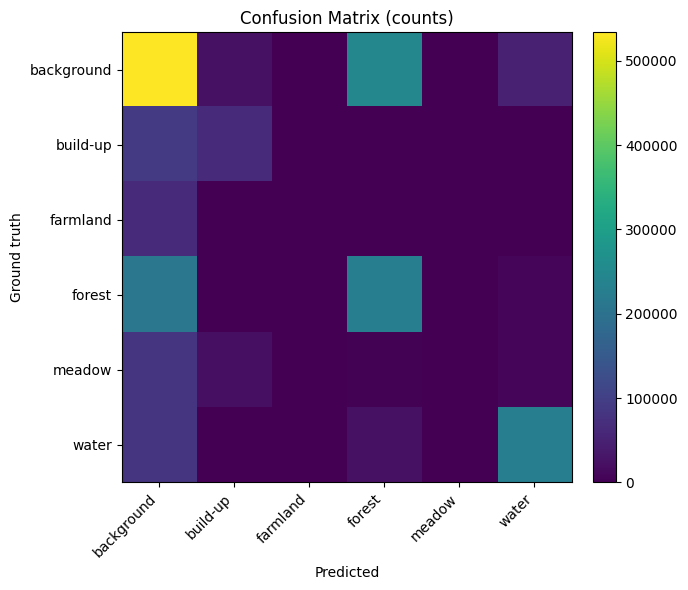

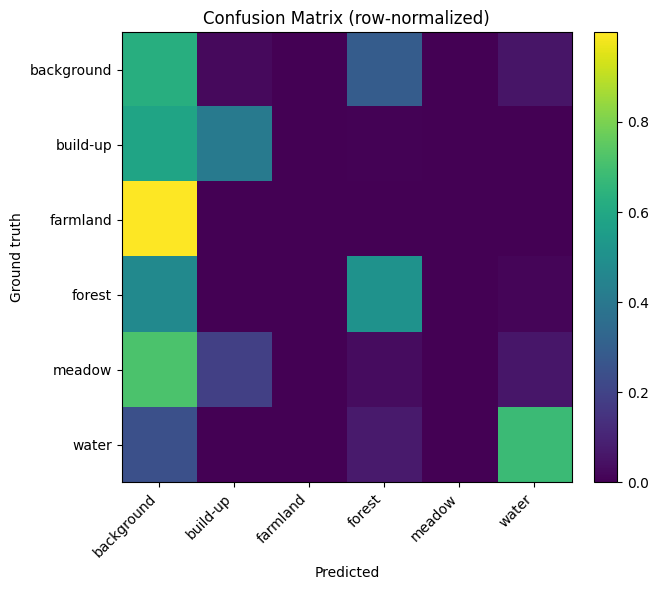

In [8]:
def plot_confusion_matrix(cm_np: np.ndarray, class_names, normalize=None, annotate=False):
    if normalize == 'true':
        sums = cm_np.sum(axis=1, keepdims=True)
        disp = cm_np / np.clip(sums, 1, None)
        title = "Confusion Matrix (row-normalized)"
    else:
        disp, title = cm_np, "Confusion Matrix (counts)"
    plt.figure(figsize=(7,6))
    im = plt.imshow(disp, cmap='viridis')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)
    plt.xlabel("Predicted"); plt.ylabel("Ground truth"); plt.title(title)
    if annotate:
        txt = disp if normalize=='true' else cm_np
        for i in range(disp.shape[0]):
            for j in range(disp.shape[1]):
                s = f"{txt[i,j]:.2f}" if normalize=='true' else f"{int(txt[i,j])}"
                plt.text(j, i, s, ha='center', va='center', color='w', fontsize=8)
    plt.tight_layout(); plt.show()

cm_np = cm.cpu().numpy()
plot_confusion_matrix(cm_np, CLASS_NAMES, normalize=None, annotate=False)
plot_confusion_matrix(cm_np, CLASS_NAMES, normalize='true', annotate=False)


In [ ]:
import numpy as np


def colorize_idx(idx_hw):
    
    if hasattr(idx_hw, "detach"):  
        idx_hw = idx_hw.detach().cpu().numpy()
    idx_hw = idx_hw.astype(np.int64, copy=False)
    lut = np.array(CLASS_COLORS, dtype=np.uint8)
    return lut[idx_hw]  


In [ ]:

import numpy as np
from PIL import Image
from pathlib import Path


CLASS_COLORS = [(0,0,0),(255,0,0),(255,255,0),(0,255,0),(0,255,255),(0,0,255)]
CLASS_NAMES  = ["background","build-up","farmland","forest","meadow","water"]
NUM_CLASSES  = len(CLASS_COLORS)
IMG_EXTS  = {".png",".jpg",".jpeg",".bmp",".tif",".tiff"}
MASK_EXTS = [".png",".tif",".tiff",".jpg",".jpeg",".bmp"]

def colorize_idx(idx_hw):
    """HxW integer array -> HxWx3 uint8 using CLASS_COLORS"""
    if hasattr(idx_hw, "detach"): idx_hw = idx_hw.detach().cpu().numpy()
    idx_hw = idx_hw.astype(np.int64, copy=False)
    lut = np.array(CLASS_COLORS, dtype=np.uint8)
    return lut[idx_hw]

def rgb_to_class(mask_rgb: np.ndarray) -> np.ndarray:
    """RGB mask with your palette -> class ids [0..NUM_CLASSES-1]."""
    out = np.zeros(mask_rgb.shape[:2], dtype=np.int64)
    for k,(r,g,b) in enumerate(CLASS_COLORS):
        m = (mask_rgb[...,0]==r) & (mask_rgb[...,1]==g) & (mask_rgb[...,2]==b)
        out[m] = k
    return out

def mask_to_class_any(mask_pil: Image.Image) -> np.ndarray:
   
    if mask_pil.mode in ("I;16", "I", "L"):     # indexed/integer labels
        arr = np.array(mask_pil, dtype=np.int64)
        return arr
    else:                                       # assume RGB colors
        rgb = np.array(mask_pil.convert("RGB"), dtype=np.uint8)
        return rgb_to_class(rgb)

def find_mask_path(img_path: Path, mask_dir: Path, suffix="_label"):
    stem = img_path.stem
    for ext in list(MASK_EXTS) + [img_path.suffix.lower()]:
        p = Path(mask_dir) / f"{stem}{suffix}{ext}"
        if p.exists(): return p
    for p in Path(mask_dir).glob(f"{stem}*label*"):
        if p.suffix.lower() in MASK_EXTS: return p
    raise FileNotFoundError(f"No mask for {img_path.name}")

def debug_show_mask_colors(mask_path: Path, max_show=20):
    im = Image.open(mask_path)
    if im.mode in ("I;16","I","L"):
        vals, cnts = np.unique(np.array(im), return_counts=True)
        print("Mask is single-channel. Unique values (value: count):")
        print(dict(zip(vals[:max_show], cnts[:max_show])))
    else:
        arr = np.array(im.convert("RGB"))
        
        flat = arr.reshape(-1,3)
        uniq, counts = np.unique(flat, axis=0, return_counts=True)
        print("Mask is RGB. First unique colors (R,G,B: count):")
        for (r,g,b),c in list(zip(uniq,counts))[:max_show]:
            print((int(r),int(g),int(b)), ":", int(c))


In [ ]:
@torch.no_grad()
def sliding_window_predict_safe(model, img_path: Path, patch_size=256, stride=192,
                                device="cuda", accumulate_on="cpu",
                                downscale_long_side=3000, amp=True):
    device = device if (device=="cuda" and torch.cuda.is_available()) else "cpu"
    acc_dev = "cpu" if accumulate_on=="cpu" else device
    with Image.open(img_path) as im:
        im = im.convert("RGB")
        W0,H0 = im.size
        scale = 1.0
        if max(W0,H0) > downscale_long_side:
            scale = downscale_long_side / float(max(W0,H0))
            im = im.resize((int(W0*scale), int(H0*scale)), Image.BILINEAR)
        W,H = im.size

        score = torch.zeros((NUM_CLASSES, H, W), dtype=torch.float32, device=acc_dev)
        count = torch.zeros((1, H, W), dtype=torch.float32, device=acc_dev)

        model.eval().to(device)
        for y in range(0,H,stride):
            for x in range(0,W,stride):
                patch = im.crop((x,y,min(x+patch_size,W),min(y+patch_size,H)))
                t = torch.from_numpy(np.array(patch, np.uint8)).permute(2,0,1).float()/255.0
                t = t.unsqueeze(0).to(device)
                with torch.autocast(device_type="cuda" if device=="cuda" else "cpu",
                                     enabled=amp, dtype=torch.float16):
                    logits = model(t)
                logits = F.interpolate(logits, size=patch.size[1::-1],
                                       mode="bilinear", align_corners=False).squeeze(0)
                if acc_dev == "cpu":
                    score[:, y:y+patch.size[1], x:x+patch.size[0]] += logits.to("cpu")
                    count[:, y:y+patch.size[1], x:x+patch.size[0]] += 1
                else:
                    score[:, y:y+patch.size[1], x:x+patch.size[0]] += logits
                    count[:, y:y+patch.size[1], x:x+patch.size[0]] += 1

        score = score / torch.clamp(count, min=1.0)
        pred = torch.argmax(score, dim=0).cpu().numpy().astype(np.int64)

        if scale != 1.0:
            pred = np.array(Image.fromarray(pred.astype(np.uint8)).resize((W0,H0), Image.NEAREST), dtype=np.int64)
        return pred

def find_mask_path(img_path: Path, mask_dir: Path, suffix="_label"):
    stem = img_path.stem
    for ext in list(MASK_EXTS) + [img_path.suffix.lower()]:
        p = Path(mask_dir) / f"{stem}{suffix}{ext}"
        if p.exists(): return p
    for p in Path(mask_dir).glob(f"{stem}*label*"):
        if p.suffix.lower() in MASK_EXTS: return p
    raise FileNotFoundError(f"No mask for {img_path.name}")

def show_full_image_triptych(img_path: Path, mask_dir: Path, model, patch_size=256, stride=192,
                             downscale_long_side=3000, overlay_alpha=0.45):
    img_path = Path(val_imgs[0])
    mask_path = find_mask_path(img_path, Path(VAL_MASK_DIR), "_label")
    img_rgb = np.array(Image.open(img_path).convert("RGB"))
    gt_idx  = rgb_to_class(np.array(Image.open(mask_path).convert("RGB")))
    pred_idx = sliding_window_predict_safe(model, img_path, patch_size, stride,
                                           device="cuda", accumulate_on="cpu",
                                           downscale_long_side=downscale_long_side, amp=True)

    debug_show_mask_colors(mask_path)
    gt_rgb   = colorize_idx(gt_idx)
    gt_idx=mask_to_class_any(Image.open(mask_path))
    pred_rgb = colorize_idx(pred_idx)
    overlay  = (img_rgb.astype(np.float32)*0.55 + pred_rgb.astype(np.float32)*0.45).astype(np.uint8)

    fig, axs = plt.subplots(1,4, figsize=(22,6))
    axs[0].imshow(img_rgb);  axs[0].set_title("Original"); axs[0].axis('off')
    axs[1].imshow(gt_rgb);   axs[1].set_title("Ground truth"); axs[1].axis('off')
    axs[2].imshow(pred_rgb); axs[2].set_title("Prediction"); axs[2].axis('off')
    axs[3].imshow(overlay);  axs[3].set_title("Overlay");   axs[3].axis('off')
    handles = [Patch(facecolor=np.array(c)/255.0, edgecolor='k', label=n)
               for c,n in zip(CLASS_COLORS, CLASS_NAMES)]
    fig.legend(handles=handles, loc="lower center", ncol=len(CLASS_NAMES), frameon=False)
    plt.tight_layout(rect=[0,0.05,1,1]); plt.show()


show_val_patches(model, val_loader, max_items=4)


val_imgs = sorted([p for p in Path(VAL_IMG_DIR).iterdir() if p.suffix.lower() in IMG_EXTS])
print(f"Found {len(val_imgs)} val files");
show_full_image_triptych(val_imgs[0], VAL_MASK_DIR, model, patch_size=256, stride=192, downscale_long_side=3000)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:

import torch, numpy as np, pandas as pd


cm_cpu = cm.to('cpu')


iou_list, miou, pa_list, mpa, oa = metrics_from_cm(cm_cpu)


support = cm_cpu.sum(dim=1).to(torch.int64).numpy()


df_per_class = pd.DataFrame({
    "class": CLASS_NAMES,
    "support_px": support,
    "PA": np.array(pa_list, dtype=float),
    "IoU": np.array(iou_list, dtype=float),
})

df_per_class["PA_%"]  = (df_per_class["PA"] * 100).round(2)
df_per_class["IoU_%"] = (df_per_class["IoU"] * 100).round(2)


df_summary = pd.DataFrame({
    "metric": ["mIoU", "mPA", "OA"],
    "value":  [miou,   mpa,   oa]
})
df_summary["value_%"] = (df_summary["value"] * 100).round(2)


from IPython.display import display
display(df_per_class[["class","support_px","PA","IoU","PA_%","IoU_%"]].round(4))
display(df_summary[["metric","value","value_%"]].round(4))

out_dir = "/content"
df_per_class.to_csv(f"{out_dir}/gid_metrics_per_class.csv", index=False)
df_summary.to_csv(f"{out_dir}/gid_metrics_summary.csv", index=False)
print("Saved:",
      f"{out_dir}/gid_metrics_per_class.csv",
      f"{out_dir}/gid_metrics_summary.csv", sep="\n")


,class,support_px,PA,IoU,PA_%,IoU_%
0,background,851355,0.6268,0.3866,62.68,38.66
1,build-up,155304,0.4131,0.3211,41.31,32.11
2,farmland,65028,0.0011,0.0011,0.11,0.11
3,forest,445814,0.5108,0.3155,51.08,31.55
4,meadow,112099,0.0000,0.0000,0.00,0.00
5,water,336480,0.6798,0.5744,67.98,57.44


,metric,value,value_%
0,mIoU,0.2664,26.64
1,mPA,0.3719,37.19
2,OA,0.5363,53.63


Saved:
/content/gid_metrics_per_class.csv
/content/gid_metrics_summary.csv
